**Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs**

Fonte de dados escolhida: DATASUS  
Tipo de dados de origem: DBC

* Foram obtidos no site do SUS os dados de pronto atendimento realizados no estado do Rio de Janeiro no ano de 2025.
* Os dados originais são disponibilizados em formato DBC e divididos em até 3 partes cada mês, com isso foi necessário:
    * Descompactá-los para o formato DBF
    * Realizar a conversão para o formato Parquet
     - Arquivos parquet conseguem otimizar o volume de dados facilitando seu tamanho e manipulação
    * Realizar o merge nos arquivos divididos para que cada mês resultasse em um arquivo único
    * Realizar o merge mês a mês para gerar o arquivo referente ao ano de 2025
    * O resultado foi o arquivo 2025_consolidado.parquet

**Primeiro passo**

1. Vamos realizar a leitura estrutural da base de dados.
2. Filtrar colunas relevantes.
3. Validar e tratar dados nulos.
4. Avaliar estatísticas gerais.


In [1]:
import pandas as pd

In [ ]:
dados = pd.read_parquet("2025_consolidado.parquet")

#### O arquivo consolidado ficou muito grande, com isso, vamos avaliar a estrutura de nossa base a partir dos dados do mês de junho com foco:

* Avaliar os dados gerais
* Verificar as colunas não possuem relevância para nosso estudo
* Remover estas colunas do arquivo consolidado do ano de 2025
* Seguir para avaliação geral dos dados


In [ ]:
dados = pd.read_parquet("06_25.parquet")
dados.head()
dados.describe()

,PA_QTDPRO,PA_QTDAPR,PA_VALPRO,PA_VALAPR,PA_DIF_VAL,NU_VPA_TOT,NU_PA_TOT,PA_VL_CF,PA_VL_CL,PA_VL_INC
count,7.515423e+06,7.515423e+06,7.515423e+06,7.515423e+06,7515423.0,7.515423e+06,7.515423e+06,7.515423e+06,7.515423e+06,7.515423e+06
mean,5.019677e+00,4.947912e+00,3.217654e+01,3.178756e+01,0.0,5.551485e-02,1.631371e+01,1.242293e-03,2.471800e-01,3.210942e-02
std,4.065186e+02,4.012537e+02,1.129047e+03,1.049153e+03,0.0,2.557010e+00,1.457000e+02,6.607070e-01,1.602941e+02,1.097026e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000e+00,1.000000e+00,3.510000e+00,3.510000e+00,0.0,0.000000e+00,3.370000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+00,1.000000e+00,1.100000e+01,1.100000e+01,0.0,0.000000e+00,1.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00
max,9.698200e+05,9.698200e+05,1.955970e+06,1.955970e+06,0.0,8.983500e+02,4.800000e+04,4.388700e+02,3.330000e+05,2.522625e+04


# Dicionário de Dados - merged.parquet

| Ordem | Coluna | Descrição | Fonte |
|---:|---|---|---|
| 1 | PA_CODUNI | Código do estabelecimento no CNES | DATASUS Informe Técnico SIASUS 2019/07 |
| 2 | PA_GESTAO | Código UF+município do gestor (ou UF0000 sob gestão estadual) | DATASUS Informe Técnico SIASUS 2019/07 |
| 3 | PA_CONDIC | Sigla do tipo de gestão habilitada | DATASUS Informe Técnico SIASUS 2019/07 |
| 4 | PA_UFMUN | Código UF+município de localização do estabelecimento | DATASUS Informe Técnico SIASUS 2019/07 |
| 5 | PA_REGCT | Código da regra contratual | DATASUS Informe Técnico SIASUS 2019/07 |
| 6 | PA_INCOUT | Incremento outros | DATASUS Informe Técnico SIASUS 2019/07 |
| 7 | PA_INCURG | Incremento urgência | DATASUS Informe Técnico SIASUS 2019/07 |
| 8 | PA_TPUPS | Tipo de estabelecimento | DATASUS Informe Técnico SIASUS 2019/07 |
| 9 | PA_TIPPRE | Tipo de prestador | DATASUS Informe Técnico SIASUS 2019/07 |
| 10 | PA_MN_IND | Indicador mantido/individual | DATASUS Informe Técnico SIASUS 2019/07 |
| 11 | PA_CNPJCPF | CNPJ do estabelecimento executante | DATASUS Informe Técnico SIASUS 2019/07 |
| 12 | PA_CNPJMNT | CNPJ da mantenedora | DATASUS Informe Técnico SIASUS 2019/07 |
| 13 | PA_CNPJ_CC | CNPJ do órgão que recebeu por cessão de crédito | DATASUS Informe Técnico SIASUS 2019/07 |
| 14 | PA_MVM | Data de processamento/movimento (AAAAMM) | DATASUS Informe Técnico SIASUS 2019/07 |
| 15 | PA_CMP | Competência de realização do procedimento (AAAAMM) | DATASUS Informe Técnico SIASUS 2019/07 |
| 16 | PA_PROC_ID | Código do procedimento ambulatorial | DATASUS Informe Técnico SIASUS 2019/07 |
| 17 | PA_TPFIN | Tipo de financiamento | DATASUS Informe Técnico SIASUS 2019/07 |
| 18 | PA_SUBFIN | Subtipo de financiamento | DATASUS Informe Técnico SIASUS 2019/07 |
| 19 | PA_NIVCPL | Complexidade do procedimento | DATASUS Informe Técnico SIASUS 2019/07 |
| 20 | PA_DOCORIG | Instrumento de registro (P/S/C/A/B/I) | DATASUS Informe Técnico SIASUS 2019/07 |
| 21 | PA_AUTORIZ | Número da APAC/autorização BPA-I | DATASUS Informe Técnico SIASUS 2019/07 |
| 22 | PA_CNSMED | CNS do profissional executante | DATASUS Informe Técnico SIASUS 2019/07 |
| 23 | PA_CBOCOD | Código CBO da ocupação do profissional | DATASUS Informe Técnico SIASUS 2019/07 |
| 24 | PA_MOTSAI | Motivo de saída | DATASUS Informe Técnico SIASUS 2019/07 |
| 25 | PA_OBITO | Indicador de óbito (APAC) | DATASUS Informe Técnico SIASUS 2019/07 |
| 26 | PA_ENCERR | Indicador de encerramento (APAC) | DATASUS Informe Técnico SIASUS 2019/07 |
| 27 | PA_PERMAN | Indicador de permanência (APAC) | DATASUS Informe Técnico SIASUS 2019/07 |
| 28 | PA_ALTA | Indicador de alta (APAC) | DATASUS Informe Técnico SIASUS 2019/07 |
| 29 | PA_TRANSF | Indicador de transferência (APAC) | DATASUS Informe Técnico SIASUS 2019/07 |
| 30 | PA_CIDPRI | CID principal | DATASUS Informe Técnico SIASUS 2019/07 |
| 31 | PA_CIDSEC | CID secundário | DATASUS Informe Técnico SIASUS 2019/07 |
| 32 | PA_CIDCAS | CID causas associadas | DATASUS Informe Técnico SIASUS 2019/07 |
| 33 | PA_CATEND | Caráter de atendimento | DATASUS Informe Técnico SIASUS 2019/07 |
| 34 | PA_IDADE | Idade do paciente | DATASUS Informe Técnico SIASUS 2019/07 |
| 35 | IDADEMIN | Idade mínima para o procedimento | DATASUS Informe Técnico SIASUS 2019/07 |
| 36 | IDADEMAX | Idade máxima para o procedimento | DATASUS Informe Técnico SIASUS 2019/07 |
| 37 | PA_FLIDADE | Compatibilidade da idade com regra SIGTAP | DATASUS Informe Técnico SIASUS 2019/07 |
| 38 | PA_SEXO | Sexo do paciente | DATASUS Informe Técnico SIASUS 2019/07 |
| 39 | PA_RACACOR | Raça/cor do paciente | DATASUS Informe Técnico SIASUS 2019/07 |
| 40 | PA_MUNPCN | UF+município de residência do paciente | DATASUS Informe Técnico SIASUS 2019/07 |
| 41 | PA_QTDPRO | Quantidade produzida/apresentada | DATASUS Informe Técnico SIASUS 2019/07 |
| 42 | PA_QTDAPR | Quantidade aprovada | DATASUS Informe Técnico SIASUS 2019/07 |
| 43 | PA_VALPRO | Valor produzido/apresentado | DATASUS Informe Técnico SIASUS 2019/07 |
| 44 | PA_VALAPR | Valor aprovado | DATASUS Informe Técnico SIASUS 2019/07 |
| 45 | PA_UFDIF | Indicador UF de residência diferente da UF do estabelecimento | DATASUS Informe Técnico SIASUS 2019/07 |
| 46 | PA_MNDIF | Indicador município de residência diferente do município do estabelecimento | DATASUS Informe Técnico SIASUS 2019/07 |
| 47 | PA_DIF_VAL | Diferença de valor unitário tabela unificada x gestor x quantidade aprovada | DATASUS Informe Técnico SIASUS 2019/07 |
| 48 | NU_VPA_TOT | Valor unitário do procedimento na tabela VPA | DATASUS Informe Técnico SIASUS 2019/07 |
| 49 | NU_PA_TOT | Valor unitário do procedimento na tabela SIGTAP | DATASUS Informe Técnico SIASUS 2019/07 |
| 50 | PA_INDICA | Indicativo da situação da produção (0 não aprovado, 5 aprovado total, 6 parcial) | DATASUS Informe Técnico SIASUS 2019/07 |
| 51 | PA_CODOCO | Código de ocorrência | DATASUS Informe Técnico SIASUS 2019/07 |
| 52 | PA_FLQT | Indicador de erro de quantidade produzida | DATASUS Informe Técnico SIASUS 2019/07 |
| 53 | PA_FLER | Indicador de erro de corpo da APAC | DATASUS Informe Técnico SIASUS 2019/07 |
| 54 | PA_ETNIA | Etnia do paciente | DATASUS Informe Técnico SIASUS 2019/07 |
| 55 | PA_VL_CF | Valor do complemento federal | DATASUS Informe Técnico SIASUS 2019/07 |
| 56 | PA_VL_CL | Valor do complemento local | DATASUS Informe Técnico SIASUS 2019/07 |
| 57 | PA_VL_INC | Valor do incremento | DATASUS Informe Técnico SIASUS 2019/07 |
| 58 | PA_SRV_C | Código do serviço especializado/classificação CBO (em alguns layouts aparece como PA_SRC_C) | DATASUS Informe Técnico SIASUS 2019/07 |
| 59 | PA_INE | Código de Identificação Nacional de Equipes | DATASUS Informe Técnico SIASUS 2019/07 |
| 60 | PA_NAT_JUR | Código da natureza jurídica | DATASUS Informe Técnico SIASUS 2019/07 |
| 61 | PA_FNTORC | Fonte orçamentária/fonte de recurso da produção (inferido pelo nome do campo; validar no informe técnico mais recente) | Inferência técnica |
| 62 | filename | Coluna técnica gerada na leitura de parquet com caminho do arquivo de origem | Pipeline local (DuckDB/PyArrow) |
| 63 | arquivo_origem | Coluna adicionada no merge para rastrear origem (PARJ2506a/parj2506b) | Pipeline local (merge_parquet_fase2.py) |


#### Vamos agora remover as colunas que não serão utilizadas em nossas análises iniciais no arquivo consolidado, através de nosso script. As colunas abaixo não exercem influência em nossos objetivos.


In [17]:
colunas_remover = [
      "PA_CODUNI",
      "PA_GESTAO",
      "PA_CONDIC",
      "PA_REGCT",
      "PA_INCOUT",
      "PA_INCURG",
      "PA_TPUPS",
      "PA_TIPPRE",
      "PA_MN_IND",
      "PA_CNPJCPF",
      "PA_CNPJMNT",
      "PA_CNPJ_CC",
      "PA_CMP",
      "PA_TPFIN",
      "PA_SUBFIN",
      "PA_DOCORIG",
      "PA_AUTORIZ",
      "PA_CNSMED",
      "PA_CBOCOD",
      "PA_MOTSAI",
      "PA_ENCERR",
      "PA_PERMAN",
      "PA_ALTA",
      "PA_TRANSF",
      "IDADEMIN",
      "IDADEMAX",
      "PA_FLIDADE",
      "PA_QTDPRO",
      "PA_QTDAPR",
      "PA_VALPRO",
      "PA_VALAPR",
      "PA_DIF_VAL",
      "NU_VPA_TOT",
      "NU_PA_TOT",
      "PA_FLQT",
      "PA_FLER",
      "PA_VL_CF",
      "PA_VL_CL",
      "PA_VL_INC",
      "PA_SRV_C",
      "PA_INE",
      "PA_NAT_JUR",
      "PA_FNTORC"
  ]

from pathlib import Path
from remove_parquet_columns import (
      ArgumentosExecucao,
      LoggerAplicacao,
      RemovedorColunasParquet,
)


base_dir = Path("")
argumentos = ArgumentosExecucao(
    arquivo_entrada= Path("2025_consolidado.parquet"),
    arquivo_saida = Path("2025_consolidado_especializado.parquet"),
    colunas_remover=tuple(colunas_remover),
    batch_size=100_000,
    compression="snappy",
)

logger = LoggerAplicacao(argumentos.arquivo_saida).criar_logger()
removedor = RemovedorColunasParquet(logger)
resultado = removedor.executar(argumentos)
print("Linhas processadas:", resultado.linhas_processadas)
print("Colunas removidas:", len(resultado.colunas_removidas))
print("Arquivo de saída:", argumentos.arquivo_saida)
print("Log:", argumentos.arquivo_saida.with_suffix(".log"))



2026-04-07 14:14:49,057 | INFO | Arquivo de entrada: 2025_consolidado.parquet
2026-04-07 14:14:49,058 | INFO | Arquivo de saida: 2025_consolidado_especializado.parquet
2026-04-07 14:14:49,058 | INFO | Colunas originais: 61
2026-04-07 14:14:49,059 | INFO | Colunas removidas: PA_CODUNI, PA_GESTAO, PA_CONDIC, PA_REGCT, PA_INCOUT, PA_INCURG, PA_TPUPS, PA_TIPPRE, PA_MN_IND, PA_CNPJCPF, PA_CNPJMNT, PA_CNPJ_CC, PA_CMP, PA_TPFIN, PA_SUBFIN, PA_DOCORIG, PA_AUTORIZ, PA_CNSMED, PA_CBOCOD, PA_MOTSAI, PA_ENCERR, PA_PERMAN, PA_ALTA, PA_TRANSF, IDADEMIN, IDADEMAX, PA_FLIDADE, PA_QTDPRO, PA_QTDAPR, PA_VALPRO, PA_VALAPR, PA_DIF_VAL, NU_VPA_TOT, NU_PA_TOT, PA_FLQT, PA_FLER, PA_VL_CF, PA_VL_CL, PA_VL_INC, PA_SRV_C, PA_INE, PA_NAT_JUR, PA_FNTORC
2026-04-07 14:14:49,060 | INFO | Colunas mantidas: 18
2026-04-07 14:14:49,060 | INFO | Batch size: 100000
2026-04-07 14:14:49,061 | INFO | Compressao: snappy
2026-04-07 14:15:27,852 | INFO | Linhas processadas: 99766257
2026-04-07 14:15:27,856 | INFO | Tamanho ent

Linhas processadas: 99766257
Colunas removidas: 43
Arquivo de saída: 2025_consolidado_especializado.parquet
Log: 2025_consolidado_especializado.log


#### Agora vamos obter os dados com o arquivo consolidado reduzido.


In [25]:
df_epecializado = pd.read_parquet("2025_consolidado_especializado.parquet")

Agora, vamos verificar os dados nulos nas colunas remanescentes.


In [19]:
possuiNulos = []
for a in df_epecializado.columns:
    qtdNulos = df_epecializado[a].isna().sum()
    qtdVazios = (df_epecializado[a] == "").sum()

    if(qtdNulos > 0):
        print(f"Coluna {a} poussí {qtdNulos} registros nulos.")

    if(qtdVazios > 0):
        print(f"Coluna {a} poussí {qtdVazios} registros vazios.")


Coluna PA_CIDCAS poussí 1166576 registros vazios.
Coluna PA_ETNIA poussí 99759312 registros vazios.


Podemos observar que não há valores nulos, mas, em duas colunas, uma quantidade significativa de registros está vazia e requer análise.

A coluna `PA_CIDCAS` é um CID que complementa o diagnóstico principal. De fato, é um campo não obrigatório, mas que pode indicar dados úteis para nossas análises. A princípio, vamos mantê-lo vazio, mas, caso seja necessário convertê-lo para numérico, faremos o tratamento na fase adequada.

A coluna `PA_ETNIA` pode ser removida, pois a coluna `PA_RACACOR`, que é preenchida com mais regularidade, exercerá a mesma função em nossos modelos. Ou seja, são dados similares.


In [ ]:
df_epecializado = df_epecializado.drop(columns=["PA_ETNIA"])

### Análises gerais da nossa base de dados

Embora nossos objetivos sejam voltados ao sexo feminino, antes faremos algumas avaliações importantes para qualificar os atendimentos com base no sexo e, a partir disso, obter dados que indiquem o quadro geral dos atendimentos.

Antes, vamos verificar como estão preenchidos os valores do campo que indica o sexo e, se necessário, adaptá-los para melhor leitura.


In [21]:
print(df_epecializado["PA_SEXO"].unique())

<ArrowStringArray>
['F', 'M', '0']
Length: 3, dtype: str


Vamos agora substituir o valor `0` por `ND` - Não Declarado.


In [26]:
df_epecializado["PA_SEXO"] = df_epecializado["PA_SEXO"].replace("0", "ND")

Vamos comparar nossa base de atendimentos, qualificada por sexo, com a base populacional do estado do Rio de Janeiro.

Dados populacionais do estado (Censo 2022):
Total de mulheres: 8.477.499 (52,8%)  
Total de homens: 7.577.675 (47,2%)  
Razão de sexo: 89,4 homens para cada 100 mulheres.


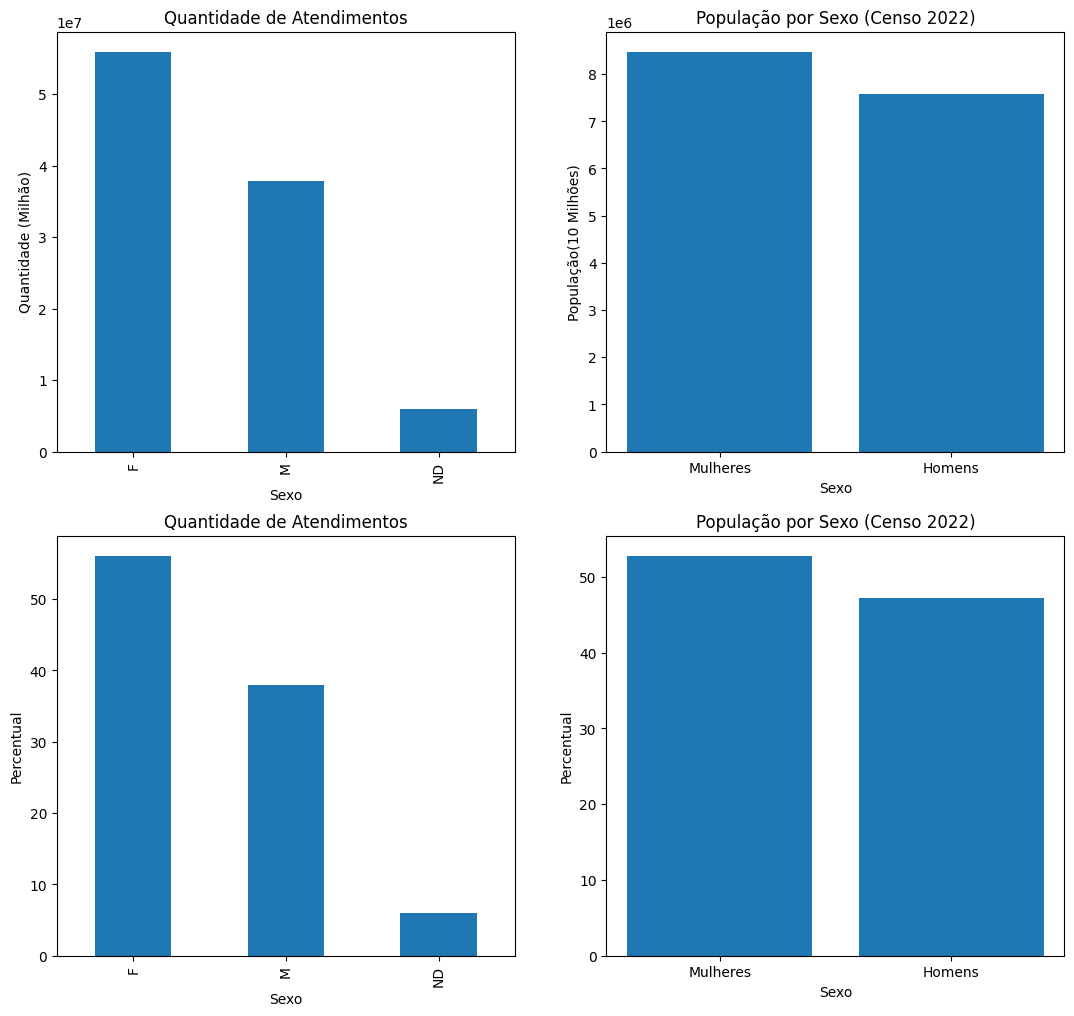

In [30]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(13, 12))
histoQtdSexo = axs[0][0]
histoQtdPop = axs[0][1]
histoPercSexo = axs[1][0]
histoPercPop = axs[1][1]

df_epecializado["PA_SEXO"].value_counts().plot(kind="bar", ax=histoQtdSexo)
histoQtdSexo.set_title("Quantidade de Atendimentos")
histoQtdSexo.set_xlabel("Sexo")
histoQtdSexo.set_ylabel("Quantidade (Milhão)")

dadosPopolucaoQtd = {
    "Sexo": ["Mulheres", "Homens"],
    "Populacao": [8477499, 7577675]
}

dadosPopolucaoQtd = pd.DataFrame(dadosPopolucaoQtd)

histoQtdPop.bar(dadosPopolucaoQtd["Sexo"], dadosPopolucaoQtd["Populacao"])

histoQtdPop.set_title("População por Sexo (Censo 2022)")
histoQtdPop.set_xlabel("Sexo")
histoQtdPop.set_ylabel("População(10 Milhões)")

(df_epecializado["PA_SEXO"].value_counts(normalize=True) * 100).plot(kind="bar", ax=histoPercSexo)
histoPercSexo.set_title("Quantidade de Atendimentos")
histoPercSexo.set_xlabel("Sexo")
histoPercSexo.set_ylabel("Percentual")

dadosPopolucaoPerc = {
    "Sexo": ["Mulheres", "Homens"],
    "Populacao": [52.8, 47.2]
}

dadosPopolucaoPerc = pd.DataFrame(dadosPopolucaoPerc)
histoPercPop.bar(dadosPopolucaoPerc["Sexo"], dadosPopolucaoPerc["Populacao"])

histoPercPop.set_title("População por Sexo (Censo 2022)")
histoPercPop.set_xlabel("Sexo")
histoPercPop.set_ylabel("Percentual")

plt.show()
